# Xarray-Spatial Multispectral: NDWI and MNDWI

Water bodies show up clearly in multispectral imagery because water absorbs near-infrared and shortwave infrared light while reflecting visible green. NDWI and MNDWI exploit that contrast to pull water features out of a scene. This notebook walks through both indices on synthetic terrain data and shows how to turn their output into a usable water mask.

### What you'll build

1. Generate synthetic green, NIR, and SWIR bands with a lake and river
2. Compute NDWI to map water using green vs. NIR contrast
3. Compute MNDWI using green vs. SWIR for better urban-area performance
4. Compare the two indices and extract a binary water mask

![Water index comparison](images/water_indices_preview.png)

[Spectral bands](#Spectral-bands) · [NDWI](#NDWI) · [MNDWI](#MNDWI) · [NDWI-vs-MNDWI](#NDWI-vs-MNDWI) · [Water mask overlay](#Water-mask-overlay)

Standard imports plus the water index functions from the multispectral module.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import xrspatial
from xrspatial.multispectral import ndwi, mndwi

## Spectral bands

We build a 400x300 synthetic scene with three land-cover types: a circular lake, a curving river channel, and surrounding terrain split between vegetation and bare soil. Each surface gets realistic reflectance values for green, NIR, and SWIR bands. Water reflects green light but absorbs NIR and SWIR. Vegetation does the opposite in NIR. Bare soil reflects moderately across all three.

In [2]:
np.random.seed(42)
rows, cols = 300, 400
y = np.arange(rows, dtype=float)
x = np.arange(cols, dtype=float)
yy, xx = np.meshgrid(y, x, indexing='ij')

# Circular lake in the upper-left quadrant
lake_dist = np.sqrt((yy - 90)**2 + (xx - 100)**2)
lake_mask = lake_dist < 45

# Curving river channel across the lower portion
river_center = 220 + 25 * np.sin(2 * np.pi * xx / 300)
river_mask = np.abs(yy - river_center) < 8

water_mask = lake_mask | river_mask

# Split remaining land: vegetation where elevation proxy is low, soil elsewhere
elev_proxy = 0.5 + 0.3 * np.sin(2 * np.pi * yy / 250) * np.cos(2 * np.pi * xx / 350)
veg_mask = (~water_mask) & (elev_proxy < 0.55)
soil_mask = (~water_mask) & (~veg_mask)

def make_band(water_val, veg_val, soil_val, noise_scale=0.01):
    band = np.where(water_mask, water_val,
                    np.where(veg_mask, veg_val, soil_val))
    band = band + np.random.normal(0, noise_scale, band.shape)
    return xr.DataArray(
        np.clip(band, 0.01, 1.0).astype(np.float32),
        dims=['y', 'x'], coords={'y': y, 'x': x},
    )

# Reflectance values (approximate Landsat-scale surface reflectance)
green_da = make_band(water_val=0.09, veg_val=0.08, soil_val=0.18)
nir_da   = make_band(water_val=0.02, veg_val=0.42, soil_val=0.28)
swir_da  = make_band(water_val=0.01, veg_val=0.18, soil_val=0.35)

Three bands, each a 2D DataArray on the same grid. Water is dark in NIR and SWIR but visible in green. Vegetation is bright in NIR. Bare soil is brightest in SWIR.

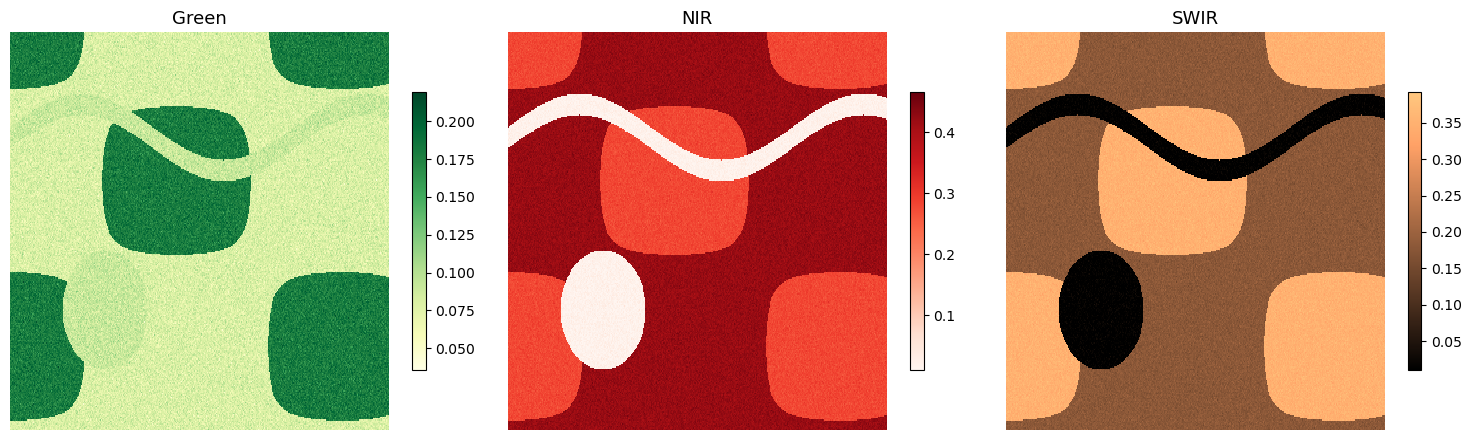

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, band, name, cmap in zip(
    axes,
    [green_da, nir_da, swir_da],
    ['Green', 'NIR', 'SWIR'],
    ['YlGn', 'Reds', 'copper'],
):
    band.plot.imshow(ax=ax, cmap=cmap, add_colorbar=True,
                     cbar_kwargs={'shrink': 0.7})
    ax.set_title(name, fontsize=13)
    ax.set_axis_off()
plt.tight_layout()

## NDWI

The [Normalized Difference Water Index](https://en.wikipedia.org/wiki/Normalized_difference_water_index) (McFeeters 1996) computes `(Green - NIR) / (Green + NIR)`. Water absorbs NIR strongly while reflecting some green light, so water pixels push NDWI positive. Vegetation does the reverse, since healthy leaves reflect NIR much more than green, and drops well below zero.

Below, NDWI is plotted with a diverging colormap. Positive values (blue) indicate water.

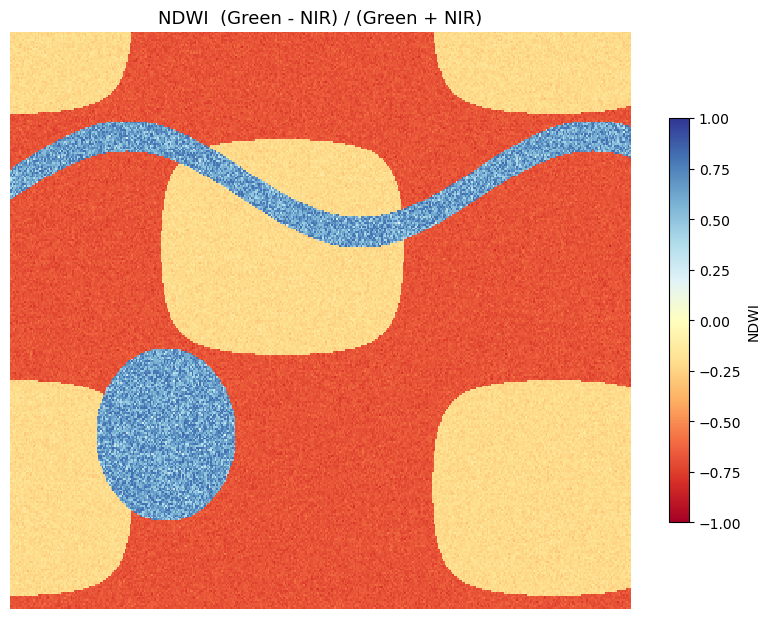

In [4]:
ndwi_result = ndwi(green_da, nir_da)

fig, ax = plt.subplots(figsize=(10, 7.5))
ndwi_result.plot.imshow(ax=ax, cmap='RdYlBu', vmin=-1, vmax=1,
                        add_colorbar=True,
                        cbar_kwargs={'label': 'NDWI', 'shrink': 0.7})
ax.set_title('NDWI  (Green - NIR) / (Green + NIR)', fontsize=13)
ax.set_axis_off()

The lake and river channel light up as strong positives. Vegetation is the most negative because of its high NIR reflectance. Bare soil sits near zero.

## MNDWI

[Modified NDWI](https://doi.org/10.1080/01431160600589179) (Xu 2006) swaps NIR for SWIR: `(Green - SWIR) / (Green + SWIR)`. Built-up surfaces like concrete and asphalt can look like water in NDWI because they also have low NIR reflectance. SWIR separates them out, since built-up surfaces reflect SWIR much more than water does. The result is fewer false positives in urban and peri-urban scenes.

The plot uses the same colormap and scale as the NDWI plot above for direct comparison.

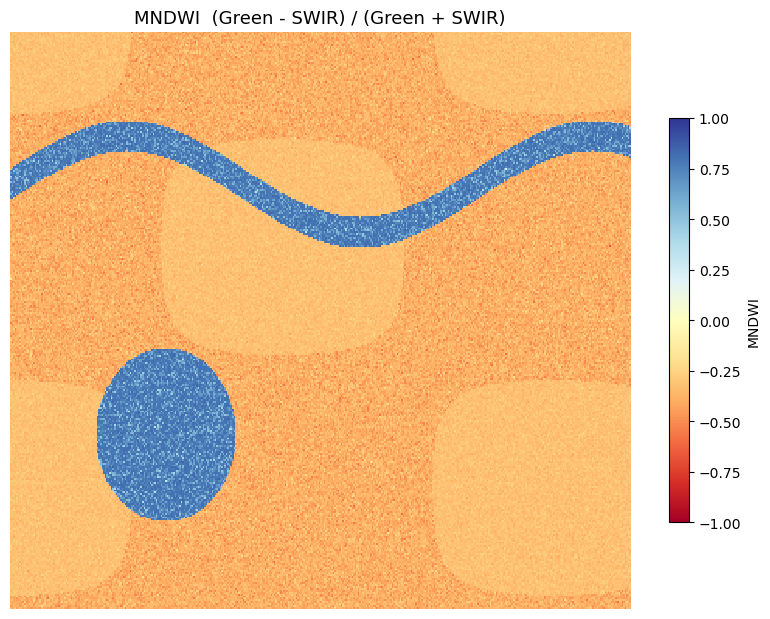

In [5]:
mndwi_result = mndwi(green_da, swir_da)

fig, ax = plt.subplots(figsize=(10, 7.5))
mndwi_result.plot.imshow(ax=ax, cmap='RdYlBu', vmin=-1, vmax=1,
                         add_colorbar=True,
                         cbar_kwargs={'label': 'MNDWI', 'shrink': 0.7})
ax.set_title('MNDWI  (Green - SWIR) / (Green + SWIR)', fontsize=13)
ax.set_axis_off()

Water features are positive here too, but the contrast between water and non-water is sharper. Vegetation drops further negative because SWIR reflectance from leaves is higher than green reflectance. In scenes with built-up surfaces, this extra separation is what eliminates false water detections.

<div class="alert alert-block alert-warning">
<b>Threshold choice matters.</b> A threshold of 0 is the standard starting point for both NDWI and MNDWI, but real-world scenes often need tuning. Turbid water, shadow, and wet soil can push thresholds to 0.1 or higher. Otsu's method or histogram-based thresholding on the index values is a common way to pick a cutoff automatically.
</div>

## NDWI vs MNDWI

Placing both indices side by side with their difference makes it easy to see where they agree and where they diverge. The difference map (MNDWI minus NDWI) highlights pixels where substituting SWIR for NIR changes the classification. In scenes with built-up land cover, those difference pixels are typically the false water detections that MNDWI eliminates.

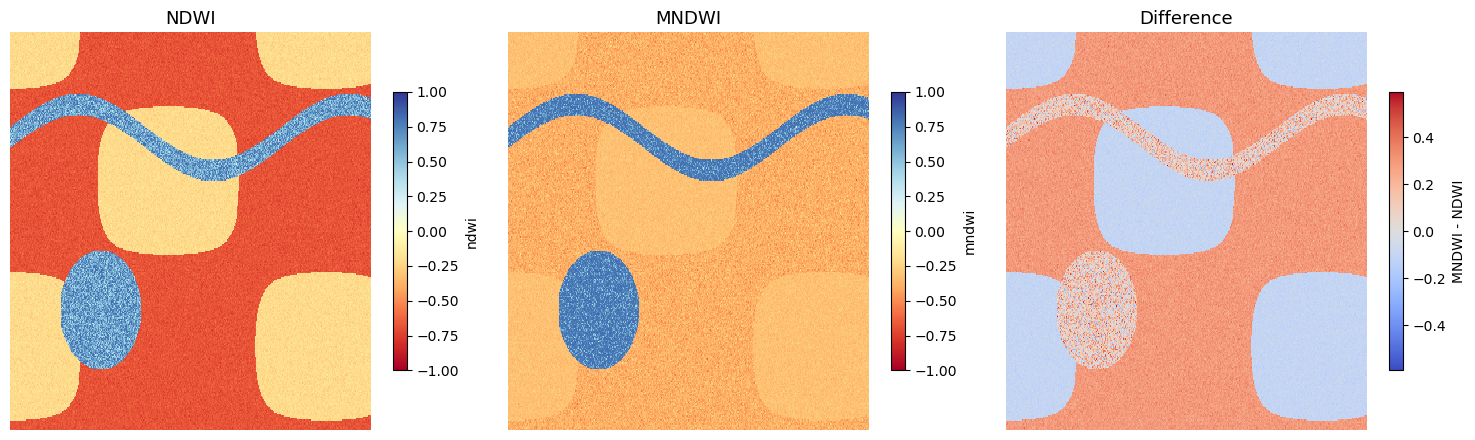

In [6]:
diff = mndwi_result - ndwi_result

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ndwi_result.plot.imshow(ax=axes[0], cmap='RdYlBu', vmin=-1, vmax=1,
                        add_colorbar=True,
                        cbar_kwargs={'shrink': 0.7})
axes[0].set_title('NDWI', fontsize=13)
axes[0].set_axis_off()

mndwi_result.plot.imshow(ax=axes[1], cmap='RdYlBu', vmin=-1, vmax=1,
                         add_colorbar=True,
                         cbar_kwargs={'shrink': 0.7})
axes[1].set_title('MNDWI', fontsize=13)
axes[1].set_axis_off()

diff.plot.imshow(ax=axes[2], cmap='coolwarm', center=0,
                 add_colorbar=True,
                 cbar_kwargs={'label': 'MNDWI - NDWI', 'shrink': 0.7})
axes[2].set_title('Difference', fontsize=13)
axes[2].set_axis_off()

plt.tight_layout()

Both indices agree on the water features. The difference is largest over vegetation, where the NIR-to-SWIR swap changes the denominator substantially. Over actual water, the difference is near zero because both NIR and SWIR are similarly low.

<div class="alert alert-block alert-danger">
<b>Band assignments differ by sensor.</b> Green is Band 3 on both Landsat 8 and Sentinel-2, but NIR is Band 5 on Landsat 8 and Band 8 on Sentinel-2. SWIR is Band 6 (Landsat 8) vs. Band 11 (Sentinel-2). Passing the wrong band silently produces garbage. Always check your sensor's band table before computing an index.
</div>

## Water mask overlay

Just for fun, let's threshold MNDWI at zero and overlay the resulting water mask on a grayscale base image. This is the typical end product: a binary mask you can use for flood mapping, shoreline extraction, or area-of-interest clipping.

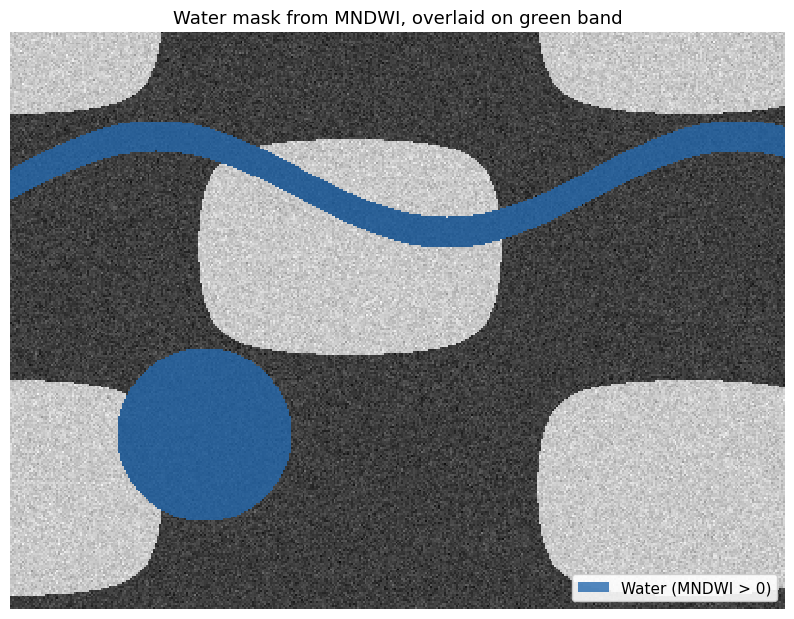

In [7]:
# Binary water mask from MNDWI > 0
water_detected = xr.where(mndwi_result > 0, 1.0, np.nan)

# Use green band as a grayscale base layer
base = green_da

fig, ax = plt.subplots(figsize=(10, 7.5))
base.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
water_detected.plot.imshow(ax=ax, cmap=ListedColormap(['#2166ac']),
                           alpha=200/255, add_colorbar=False)
ax.legend(
    handles=[Patch(facecolor='#2166ac', alpha=0.78, label='Water (MNDWI > 0)')],
    loc='lower right', fontsize=11, framealpha=0.9,
)
ax.set_title('Water mask from MNDWI, overlaid on green band', fontsize=13)
ax.set_axis_off()

### References

- McFeeters, S.K., 1996. [The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features](https://en.wikipedia.org/wiki/Normalized_difference_water_index). International Journal of Remote Sensing, 17(7), pp.1425-1432.
- Xu, H., 2006. [Modification of normalised difference water index (NDWI) to enhance open water features in remotely sensed imagery](https://doi.org/10.1080/01431160600589179). International Journal of Remote Sensing, 27(14), pp.3025-3033.
- [Landsat 8 band designations](https://www.usgs.gov/faqs/what-are-band-designations-landsat-satellites), USGS
- [Sentinel-2 band index list](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/indexdb/), Sentinel Hub
- [xrspatial multispectral API docs](https://makepath.github.io/xarray-spatial/reference/_autosummary/xrspatial.multispectral.html)